In [ ]:
!pip install -U sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 24.0 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from torch.nn import functional as F
import random

#model_name = 'gpt2'
model_name = 'allegro/herbert-base-cased'
device = 'cuda'
#device = 'cpu'

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

If you want to use `BertLMHeadModel` as a standalone, add `is_decoder=True.`


model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

In [ ]:
emb_pos = model.transformer.wpe.weight.detach().cpu().numpy()


In [ ]:
emb_pos.shape

(1024, 768)

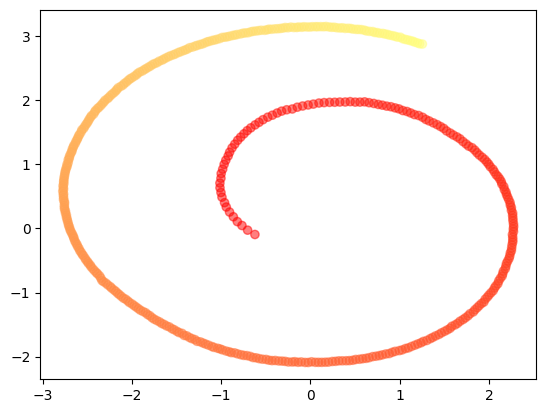

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
%matplotlib inline

pca = PCA(n_components=2)
X_pca = pca.fit_transform(emb_pos)
M = 500
S = 10
X_pca = X_pca[S:S+M,:]

cs = [(1.0, int(k)/M, 0.5*int(k)/M) for k in range(X_pca.shape[0])]

# Plot the two most important components
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, c=cs)
None

# Zadanie 1

In [ ]:
clusters_txt = '''
piśmiennicze: pisak flamaster ołówek długopis pióro
małe_ssaki: mysz szczur chomik łasica kuna bóbr
okręty: niszczyciel lotniskowiec trałowiec krążownik pancernik fregata korweta
lekarze: lekarz pediatra ginekolog kardiolog internista geriatra
zupy: rosół żurek barszcz
uczucia: miłość przyjaźń nienawiść gniew smutek radość strach
działy_matematyki: algebra analiza topologia logika geometria
budynki_sakralne: kościół bazylika kaplica katedra świątynia synagoga zbór
stopień_wojskowy: chorąży podporucznik porucznik kapitan major pułkownik generał podpułkownik
grzyby_jadalne: pieczarka borowik gąska kurka boczniak kania
prądy_filozoficzne: empiryzm stoicyzm racjonalizm egzystencjalizm marksizm romantyzm
religie: chrześcijaństwo buddyzm islam prawosławie protestantyzm kalwinizm luteranizm judaizm
dzieła_muzyczne: sonata synfonia koncert preludium fuga suita
cyfry: jedynka dwójka trójka czwórka piątka szóstka siódemka ósemka dziewiątka
owady: ważka biedronka żuk mrówka mucha osa pszczoła chrząszcz
broń_biała: miecz topór sztylet nóż siekiera
broń_palna: karabin pistolet rewolwer fuzja strzelba
komputery: komputer laptop kalkulator notebook
kolory: biel żółć czerwień błękit zieleń brąz czerń
duchowny: wikary biskup ksiądz proboszcz rabin pop arcybiskup kardynał pastor
ryby: karp śledź łosoś dorsz okoń sandacz szczupak płotka
napoje_mleczne: jogurt kefir maślanka
czynności_sportowe: bieganie skakanie pływanie maszerowanie marsz trucht
ubranie:  garnitur smoking frak żakiet marynarka koszula bluzka sweter sweterek sukienka kamizelka spódnica spodnie
mebel: krzesło fotel kanapa łóżko wersalka sofa stół stolik ława
przestępca: morderca zabójca gwałciciel złodziej bandyta kieszonkowiec łajdak łobuz
mięso_wędliny wieprzowina wołowina baranina cielęcina boczek baleron kiełbasa szynka schab karkówka dziczyzna
drzewo: dąb klon wiąz jesion świerk sosna modrzew platan buk cis jawor jarzębina akacja
źródło_światła: lampa latarka lampka żyrandol żarówka reflektor latarnia lampka
organ: wątroba płuco serce trzustka żołądek nerka macica jajowód nasieniowód prostata śledziona
oddziały: kompania pluton batalion brygada armia dywizja pułk
napój_alkoholowy: piwo wino wódka dżin nalewka bimber wiśniówka cydr koniak wiśniówka
kot_drapieżny: puma pantera lampart tygrys lew ryś żbik gepard jaguar
metal: żelazo złoto srebro miedź nikiel cyna cynk potas platyna chrom glin aluminium
samolot: samolot odrzutowiec awionetka bombowiec myśliwiec samolocik helikopter śmigłowiec
owoc: jabłko gruszka śliwka brzoskwinia cytryna pomarańcza grejpfrut porzeczka nektaryna
pościel: poduszka prześcieradło kołdra kołderka poduszeczka pierzyna koc kocyk pled
agd: lodówka kuchenka pralka zmywarka mikser sokowirówka piec piecyk piekarnik
'''

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from torch.nn import functional as F
import random
import numpy as np

# ----------------- MODEL -----------------

#model_name = 'gpt2'
model_name = 'sdadas/polish-gpt2-medium'
#model_name = 'allegro/herbert-base-cased'
device = 'cuda'
#device = 'cpu'

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

# wejściowe embeddingi tokenów GPT-2 (bezkontekstowe)
emb = model.transformer.wte.weight.detach().cpu().numpy()

# ----------------- FUNKCJE DO SŁÓW -----------------

def word_to_token_ids(word):
    """
    Dla GPT-2 dodajemy spację z przodu, bo model był trenowany
    na tokenach typu ' słowo' w środku zdania.
    """
    enc = tokenizer(' ' + word, return_tensors='pt', add_special_tokens=False)
    return enc['input_ids'][0].tolist()

def token_ids_to_embedding(token_ids, normalize=False):
    """
    Średnia embeddingów tokenów (wejściowych, z emb).
    """
    vecs = emb[token_ids]
    v = vecs.mean(axis=0)
    if normalize:
        v = v / np.linalg.norm(v)
    return v

def word_embedding(word, normalize=False):
    ids = word_to_token_ids(word)
    return token_ids_to_embedding(ids, normalize=normalize)

# ----------------- ZBIERANIE SŁÓW Z KLASTRÓW -----------------

words = set()

for line in clusters_txt.split('\n'):
    L = line.split()
    if len(L) < 2:
        continue
    # L[0] – nazwa klastra (z dwukropkiem albo bez),
    # L[1:] – interesujące nas słowa
    words.update(L[1:])

print("Liczba słów do osadzenia:", len(words))

D = emb.shape[1]
print("Wymiar embeddingów:", D)

# ----------------- PIERWSZA WERSJA: SUROWE WEKTORY -----------------

word_vectors = {}

for w in sorted(words):
    vec = word_embedding(w, normalize=False)
    word_vectors[w] = vec

fname = "word_embedings_file.txt"

with open(fname, "w", encoding="utf-8") as f:
    for w in sorted(word_vectors.keys()):
        v = word_vectors[w]
        floats_str = " ".join(f"{x:.6f}" for x in v)
        f.write(f"{w} {floats_str}\n")

print("Zapisano plik (surowe wektory):", fname)

with open("word_embedings_file.txt", encoding="utf-8") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 4:
            break

# ----------------- ALL-BUT-THE-TOP NA WEKTORACH -----------------

words_list = sorted(words)
print("Liczba słów:", len(words_list))

X = np.stack([word_embedding(w, normalize=False) for w in words_list])
print("Shape X:", X.shape)

mu = X.mean(axis=0)
Xc = X - mu

U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

n_remove = 3
pcs = Vt[:n_remove]

print("Usuwam", n_remove, "pierwsze składowe główne")

def remove_top_pcs(v, mean=mu, pcs=pcs):
    """
    v – wektor oryginalny (1D, dim)
    mean – wektor średni
    pcs – macierz (n_remove, dim) głównych składowych
    """
    v = v - mean
    for pc in pcs:
        v = v - np.dot(pc, v) * pc
    return v

word_vectors = {}

for i, w in enumerate(words_list):
    v_orig = X[i]
    v_proc = remove_top_pcs(v_orig)
    word_vectors[w] = v_proc

fname = "word_embedings_file.txt"

with open(fname, "w", encoding="utf-8") as f:
    for w in sorted(word_vectors.keys()):
        v = word_vectors[w]
        floats_str = " ".join(f"{x:.6f}" for x in v)
        f.write(f"{w} {floats_str}\n")

print("Zapisano plik (po all-but-the-top):", fname)


Liczba słów do osadzenia: 288
Wymiar embeddingów: 1024
Zapisano plik (surowe wektory): word_embedings_file.txt
akacja 0.021233 0.046207 -0.006256 -0.056625 0.048050 0.069977 -0.040031 0.005524 0.007507 0.032486 -0.005531 0.000847 -0.045895 -0.030258 -0.024993 0.038990 -0.022598 0.010765 0.023584 -0.038984 -0.018501 0.022343 -0.030159 -0.014046 -0.010300 -0.075378 0.028933 -0.065506 0.012207 0.009168 -0.067490 0.004753 -0.013699 -0.049225 0.011307 -0.085098 -0.024307 -0.033963 0.062317 0.029686 -0.020584 -0.002831 -0.012695 0.024605 -0.040115 0.002661 -0.037224 0.019150 0.050293 0.024483 0.036335 0.080688 0.035858 -0.056168 0.012228 0.020523 0.055832 -0.022659 -0.040794 -0.024063 -0.043396 0.011570 -0.003117 0.007339 -0.064423 -0.001343 -0.039215 0.021545 -0.006592 -0.026878 -0.030853 -0.005638 0.008789 -0.033897 -0.048683 -0.020981 -0.015072 0.014085 -0.007553 -0.018036 -0.018356 0.005478 0.033997 0.025436 -0.024577 -0.036884 -0.052673 -0.001080 -0.011881 -0.011505 0.044708 -0.021862 -

b)

In [ ]:
def contextual_word_embedding(word, layer_indices=(-4, -3, -2, -1)):
    """
    Zwraca kontekstowy embedding słowa na podstawie hidden states HerBERT-a.
    - layer_indices: które warstwy uśredniać (domyślnie ostatnie 4)
    """
    # U BERT-a/HerBERT-a NIE dodajemy spacji z przodu, i zwykle chcemy specjalne tokeny,
    # ale tu tekst to jedno słowo, więc weźmiemy bez special tokens, żeby było prościej
    enc = tokenizer(word, return_tensors='pt', add_special_tokens=False)
    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        out = model(**enc, output_hidden_states=True)

    hidden_states = out.hidden_states
    # wybieramy warstwy po indeksach relative (np. -1 = ostatnia)
    selected = [hidden_states[i][0] for i in layer_indices]

    # stos: (num_layers, seq_len, dim)
    stacked = torch.stack(selected, dim=0)
    # najpierw średnia po warstwach, potem średnia po tokenach
    v = stacked.mean(dim=0).mean(dim=0)

    return v.cpu().numpy()

In [ ]:
words = set()
for line in clusters_txt.split('\n'):
    L = line.split()
    if len(L) < 2:
        continue
    words.update(L[1:])

words_list = sorted(words)
print("Liczba słów:", len(words_list))

word_vectors = {}

for w in words_list:
    #v = contextual_word_embedding(w, layer_indices=(-4, -3, -2, -1))
    v = contextual_word_embedding(w, layer_indices=(1,))
    word_vectors[w] = v

fname = "word_embedings_file.txt"

with open(fname, "w", encoding="utf-8") as f:
    for w in sorted(word_vectors.keys()):
        v = word_vectors[w]
        floats_str = " ".join(f"{x:.6f}" for x in v)
        f.write(f"{w} {floats_str}\n")

print("Zapisano plik:", fname)

Liczba słów: 288
Zapisano plik: word_embedings_file.txt


c)

In [ ]:
static_vecs = []
ctx_vecs = []

for w in words_list:
    vs = word_embedding(w)
    vc = contextual_word_embedding(w, layer_indices=(1,))
    static_vecs.append(vs)
    ctx_vecs.append(vc)

static_vecs = np.stack(static_vecs)  # (N, D)
ctx_vecs    = np.stack(ctx_vecs)     # (N, D)

X = np.concatenate([static_vecs, ctx_vecs], axis=1)  # (N, 2D)
print("Shape X (combined):", X.shape)

Shape X (combined): (288, 1536)


In [ ]:
mu = X.mean(axis=0)
Xc = X - mu

U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

n_remove = 2
pcs = Vt[:n_remove]

def remove_top_pcs(v, mean=mu, pcs=pcs):
    v = v - mean
    for pc in pcs:
        v = v - np.dot(pc, v) * pc
    return v

X_clean = np.stack([remove_top_pcs(X[i]) for i in range(len(words_list))])
print("Shape X_clean:", X_clean.shape)

Shape X_clean: (288, 1536)


In [ ]:
fname = "word_embedings_file.txt"

with open(fname, "w", encoding="utf-8") as f:
    for i, w in enumerate(words_list):
        v = X_clean[i]         # (2D,)
        floats_str = " ".join(f"{x:.6f}" for x in v)
        f.write(f"{w} {floats_str}\n")

print("Zapisano plik:", fname)

Zapisano plik: word_embedings_file.txt
